# Renger 2026 Hamiltonian Simulation Workflow

**Audience**
- Julia users who already know the basic `QuantumCircuit.jl` architecture and want a compact closed-system workflow for the Renger 2026 qubit-resonator processor.

**Prerequisites**
- Basic Julia syntax.
- Familiarity with `CompositeSystem`, `spectrum`, and `evolve`.
- A working local checkout of this repository.

**What you will learn**
- How to move from small didactic exchange models to the reduced paper-aligned `QB1-TC1-CR-TC2-QB2` device.
- How to compare effective and exact-circuit Hamiltonians at the parked operating point.
- How to extract MOVE and CZ metrics from projected unitaries.
- How the paper's logical remote entangling workflow is organized as `MOVE(QB1, CR) -> CZ(QB2, CR) -> MOVE(QB1, CR)`.

**Runtime profile**
- Default cells use reduced truncations and coarse scans so the tutorial stays interactive.
- The optional five-body exact-circuit extension is guarded behind a flag and is skipped by default.


## Outline

1. Activate the local package environment and load notebook helpers.
2. Load the frozen Renger parameter snapshot and review the inferred local priors.
3. Reproduce clean qubit-resonator MOVE physics in a tiny resonant `Q-R` model.
4. Add an explicit tunable coupler in a resonant `Q-C-R` model and inspect mediated transfer.
5. Build the reduced paper device and inspect the parked effective and exact-circuit models.
6. Compare effective versus exact-circuit spectra and one avoided-crossing proxy sweep.
7. Review the remote logical gate concept `MOVE -> CZ -> MOVE`.
8. Use a compact exact-circuit testbed to calibrate the CZ phase-extraction machinery.
9. Assemble a reduced remote-gate workflow summary from the calibrated MOVE and CZ ingredients.
10. Optionally map the same ideas onto the reduced five-body exact-circuit model.
11. Review pitfalls, convergence checks, and one exercise.


In [2]:
using Pkg

function find_repo_root(start::AbstractString)
    candidates = [
        normpath(start),
        normpath(joinpath(start, "..")),
        normpath(joinpath(start, "..", "..")),
    ]

    for candidate in unique(candidates)
        project_toml = joinpath(candidate, "Project.toml")
        if isfile(project_toml)
            content = read(project_toml, String)
            occursin("QuantumCircuit", content) && return candidate
        end
    end

    error("Could not find the QuantumCircuit.jl project root. Start Jupyter from the repository or open the notebook from inside it.")
end

project_root = find_repo_root(pwd())
Pkg.activate(project_root)
Pkg.instantiate()

using CairoMakie
using QuantumCircuit

include(joinpath(project_root, "output", "jupyter-notebook", "makie_helpers.jl"))
activate_notebook_theme!()

figure_exports = Dict{Symbol, NamedTuple}()


  Activating project at `~/Research/20_Projects/QuantumCircuit.jl`


Dict{Symbol, NamedTuple}()

In [3]:
RUN_OPTIONAL_FIVE_BODY = false

function snapshot_rows(snapshot)
    rows = NamedTuple[]
    for device_name in [:QB1, :TC1, :CR, :TC2, :QB2]
        if device_name == :CR
            push!(rows, (
                name = String(device_name),
                type = "Resonator",
                fit = "paper target",
                f01_ghz = snapshot.targets["cr_f01_ghz"],
                EC = missing,
                EJ_or_EJmax = missing,
                flux = missing,
                asymmetry = missing,
            ))
        else
            data = snapshot.devices[device_name]
            push!(rows, (
                name = String(device_name),
                type = data["type"],
                fit = data["fit_classification"],
                f01_ghz = data["f01_ghz"],
                EC = data["EC"],
                EJ_or_EJmax = data["EJmax"],
                flux = data["flux"],
                asymmetry = data["asymmetry"],
            ))
        end
    end
    rows
end

function subsystem_rows(system)
    rows = NamedTuple[]
    for subsystem in subsystems(system)
        if subsystem isa Resonator
            push!(rows, (
                name = String(name(subsystem)),
                type = string(nameof(typeof(subsystem))),
                truncation = subsystem.dim,
                frequency_or_energy = subsystem.ω,
                EC = missing,
                flux = missing,
            ))
        elseif subsystem isa Transmon
            push!(rows, (
                name = String(name(subsystem)),
                type = string(nameof(typeof(subsystem))),
                truncation = subsystem.ncut,
                frequency_or_energy = subsystem.EJ,
                EC = subsystem.EC,
                flux = missing,
            ))
        else
            push!(rows, (
                name = String(name(subsystem)),
                type = string(nameof(typeof(subsystem))),
                truncation = subsystem.ncut,
                frequency_or_energy = subsystem.EJmax,
                EC = subsystem.EC,
                flux = subsystem.flux,
            ))
        end
    end
    rows
end

function coupling_rows(system)
    rows = NamedTuple[]
    for coupling in couplings(system)
        source, target = coupling_endpoints(coupling)
        strength_name = coupling isa CapacitiveCoupling ? :g : :G
        strength = getproperty(coupling, strength_name)
        push!(rows, (
            source = String(source),
            target = String(target),
            type = string(nameof(typeof(coupling))),
            parameter = String(strength_name),
            strength = strength,
        ))
    end
    rows
end

function spectrum_summary(result)
    freqs = transition_frequencies(result)
    return (
        energies = round.(result.energies; digits = 6),
        transition_01 = round(freqs[1]; digits = 6),
        transition_12 = length(freqs) >= 2 ? round(freqs[2]; digits = 6) : missing,
        anharmonicity = length(result.energies) >= 3 ? round(anharmonicity(result); digits = 6) : missing,
    )
end

function move_summary(best)
    return (
        best_time = round(best.time; digits = 3),
        transfer_probability = round(best.transfer_probability; digits = 6),
        leakage = round(best.leakage; digits = 6),
    )
end

function cz_summary(best)
    return (
        best_time = round(best.time; digits = 3),
        conditional_phase = round(best.conditional_phase; digits = 6),
        conditional_phase_over_pi = round(best.conditional_phase / pi; digits = 6),
        phase_error = round(best.phase_error; digits = 6),
        leakage = round(best.leakage; digits = 6),
    )
end

function build_toy_qr()
    CompositeSystem(
        Transmon(:q; EJ = 0.9, EC = 0.2, ncut = 3),
        Resonator(:r; ω = 1.0, dim = 2),
        CapacitiveCoupling(:q, :r; g = 0.08),
    )
end

function build_toy_qcr()
    CompositeSystem(
        Transmon(:q; EJ = 0.9, EC = 0.2, ncut = 3),
        TunableCoupler(:c; EJmax = 1.1, EC = 0.15, flux = 0.0, asymmetry = 0.1, ncut = 3),
        Resonator(:r; ω = 1.0, dim = 2),
        CapacitiveCoupling(:q, :c; g = 0.07),
        CapacitiveCoupling(:c, :r; g = 0.07),
    )
end

function build_compact_cz_testbed()
    system = CompositeSystem(
        Transmon(:q1; EJ = 0.9, EC = 0.2, ng = 0.0, ncut = 3),
        TunableCoupler(:c; EJmax = 2.6, EC = 0.12, flux = 0.0, asymmetry = 0.1, ng = 0.0, ncut = 3),
        Transmon(:q2; EJ = 0.95, EC = 0.2, ng = 0.0, ncut = 3),
        CircuitCapacitiveCoupling(:q1, :c; G = 0.03),
        CircuitCapacitiveCoupling(:c, :q2; G = 0.03),
    )
    return (; system, hamiltonian_spec = CircuitHamiltonianSpec(charge_cutoff = 2))
end


build_compact_cz_testbed (generic function with 1 method)

## Step 1 - Load the frozen Renger parameter snapshot

The local parameter priors used here come from `Renger2026_PLAN.md` and `output/renger2026/paper_local_priors.toml`.

Two important modeling rules apply throughout this notebook:
- `QB1` and `QB2` are treated as frozen local priors.
- `TC1`, `TC2`, and the `beta_*` couplings are only seeded starting points for later coupled fitting, not validated device truth.

The early MOVE sections below therefore use tiny resonant teaching models so the exchange physics is obvious. The notebook switches back to the paper-aligned reduced builders once the physics is established.


In [4]:
snapshot = load_renger2026_snapshot()
parameter_rows = snapshot_rows(snapshot)

stage_builder_preview = (
    qr_builder_couplings = coupling_rows(renger2026_stage1_qr_system(snapshot).system),
    qcr_builder_couplings = coupling_rows(renger2026_stage1_qcr_system(snapshot).system),
)

display(parameter_rows)
stage_builder_preview


5-element Vector{NamedTuple}:
 (name = "QB1", type = "TunableTransmon", fit = "identified", f01_ghz = 4.67066, EC = 0.199460916442, EJ_or_EJmax = 14.92, flux = 0.0, asymmetry = 0.1)
 (name = "TC1", type = "TunableCoupler", fit = "weakly identified", f01_ghz = 5.25661, EC = 0.105, EJ_or_EJmax = 34.25, flux = 0.0, asymmetry = 0.1)
 (name = "CR", type = "Resonator", fit = "paper target", f01_ghz = 4.22, EC = missing, EJ_or_EJmax = missing, flux = missing, asymmetry = missing)
 (name = "TC2", type = "TunableCoupler", fit = "weakly identified", f01_ghz = 5.25661, EC = 0.105, EJ_or_EJmax = 34.25, flux = 0.0, asymmetry = 0.1)
 (name = "QB2", type = "TunableTransmon", fit = "identified", f01_ghz = 4.46979, EC = 0.200581395349, EJ_or_EJmax = 13.65, flux = 0.0, asymmetry = 0.1)

(qr_builder_couplings = NamedTuple[(source = "QB1", target = "CR", type = "CapacitiveCoupling", parameter = "g", strength = 0.00887923086759208)], qcr_builder_couplings = NamedTuple[(source = "QB1", target = "TC1", type = "CapacitiveCoupling", parameter = "g", strength = 0.08423467931969232), (source = "TC1", target = "CR", type = "CapacitiveCoupling", parameter = "g", strength = 0.10597211986532118)])

## Step 2 - Native MOVE in a resonant `Q-R` toy model

This is the smallest model that cleanly shows qubit-resonator exchange. The transmon frequency and resonator frequency are intentionally matched so the single excitation swaps almost perfectly.

We use this section to make the meaning of MOVE concrete before bringing back the tunable coupler and the paper-aligned device.


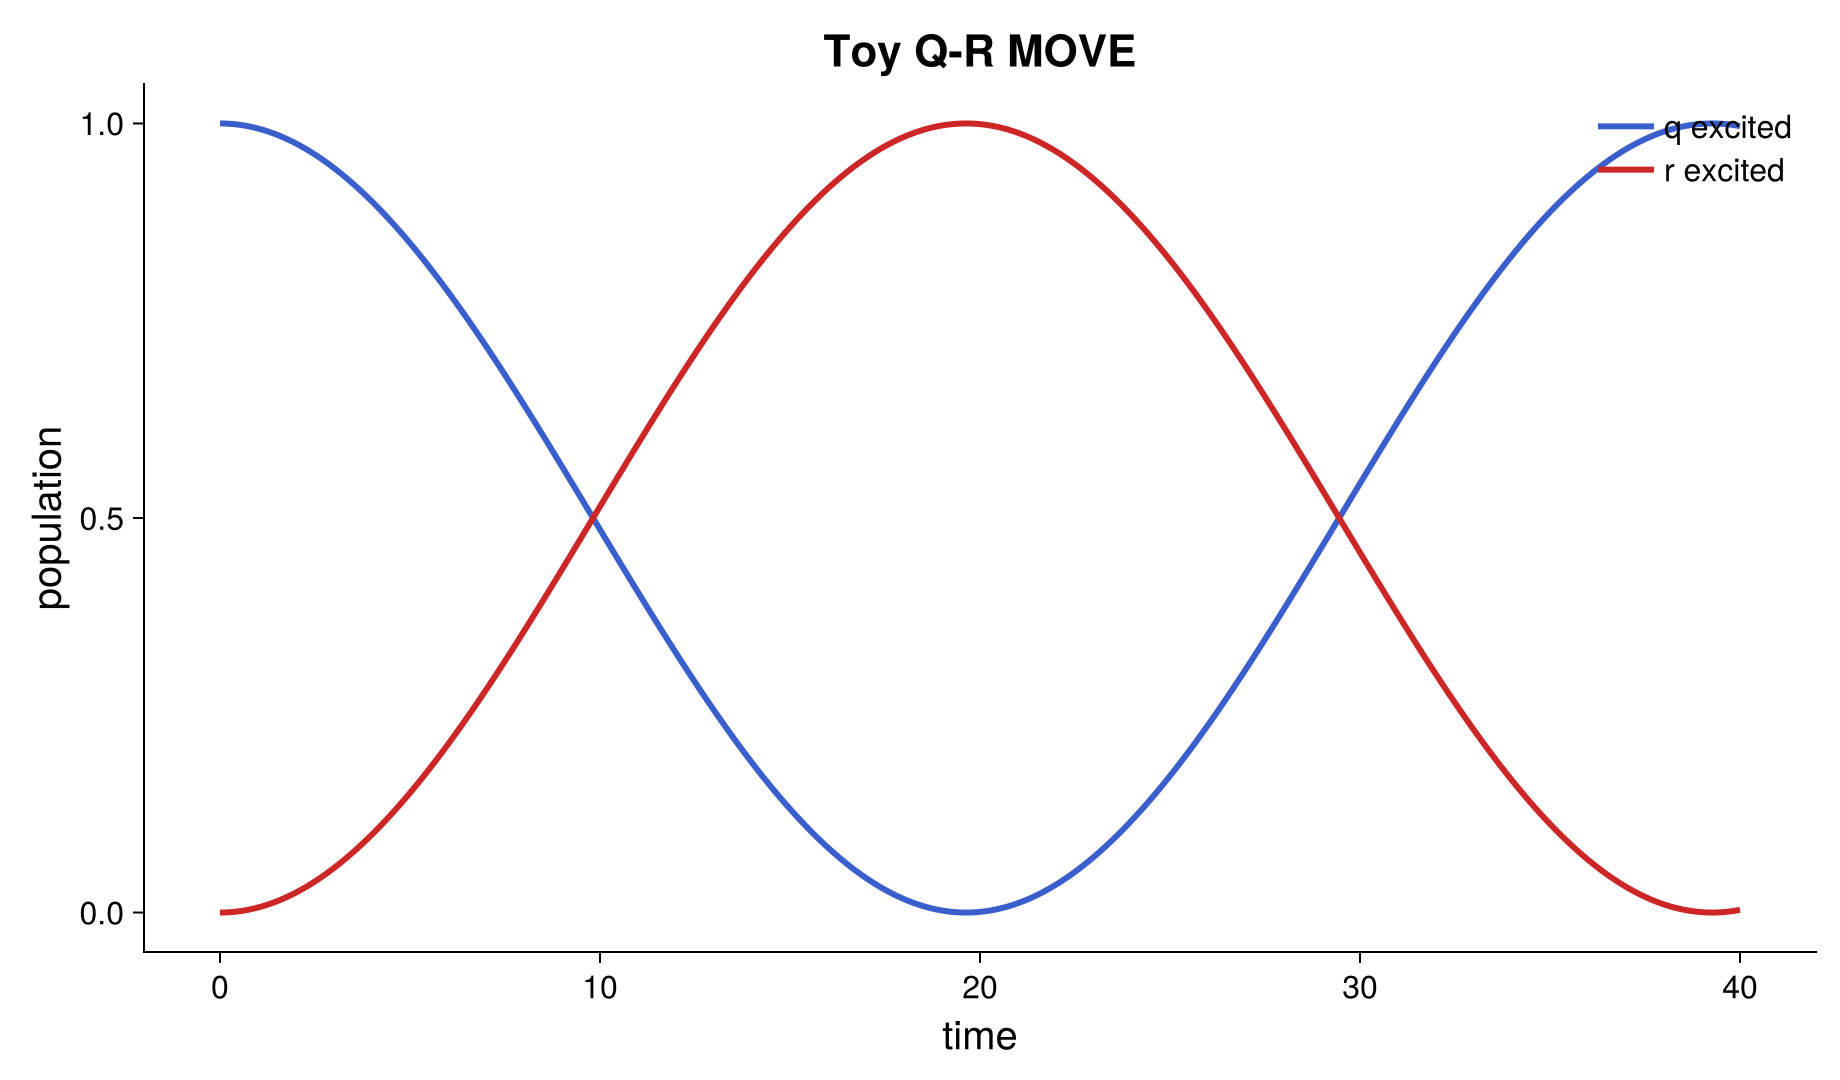

(move = (best_time = 19.6, transfer_probability = 0.999992, leakage = 0.0), saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/workflow_toy_qr_move.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/workflow_toy_qr_move.png"))

In [5]:
toy_qr = build_toy_qr()
qr_subspace = subspace_spec(toy_qr; subsystem_levels = (q = [0, 1], r = [0, 1]))
qr_tlist = collect(range(0.0, 40.0; length = 401))

qr_trace = projected_unitary(toy_qr, qr_subspace, qr_tlist)
qr_best = best_move(qr_trace; source_index = 3, target_index = 2)

qr_result = evolve(toy_qr, basis_state(toy_qr; q = 1, r = 0), qr_tlist)
q_population = population_trace(qr_result, :q, 1)
r_population = population_trace(qr_result, :r, 1)

qr_fig = line_figure(
    [
        (x = q_population.times, y = q_population.values, label = "q excited", color = :royalblue3),
        (x = r_population.times, y = r_population.values, label = "r excited", color = :firebrick3),
    ];
    title = "Toy Q-R MOVE",
    xlabel = "time",
    ylabel = "population",
)
qr_saved = save_figure(qr_fig, project_root, "workflow_toy_qr_move")
figure_exports[:workflow_toy_qr_move] = qr_saved

display(qr_fig)
(
    move = move_summary(qr_best),
    saved = qr_saved,
)


## Step 3 - Mediated MOVE in a resonant `Q-C-R` toy model

Now we add an explicit tunable coupler. The coupler is tuned close enough to resonance that the excitation still reaches the resonator efficiently, but the evolution now shows strong transient coupler participation.

This is the cleanest small model for the paper's left half device physics: the coupler is no longer a hidden effective correction; it becomes an explicit dynamical degree of freedom.


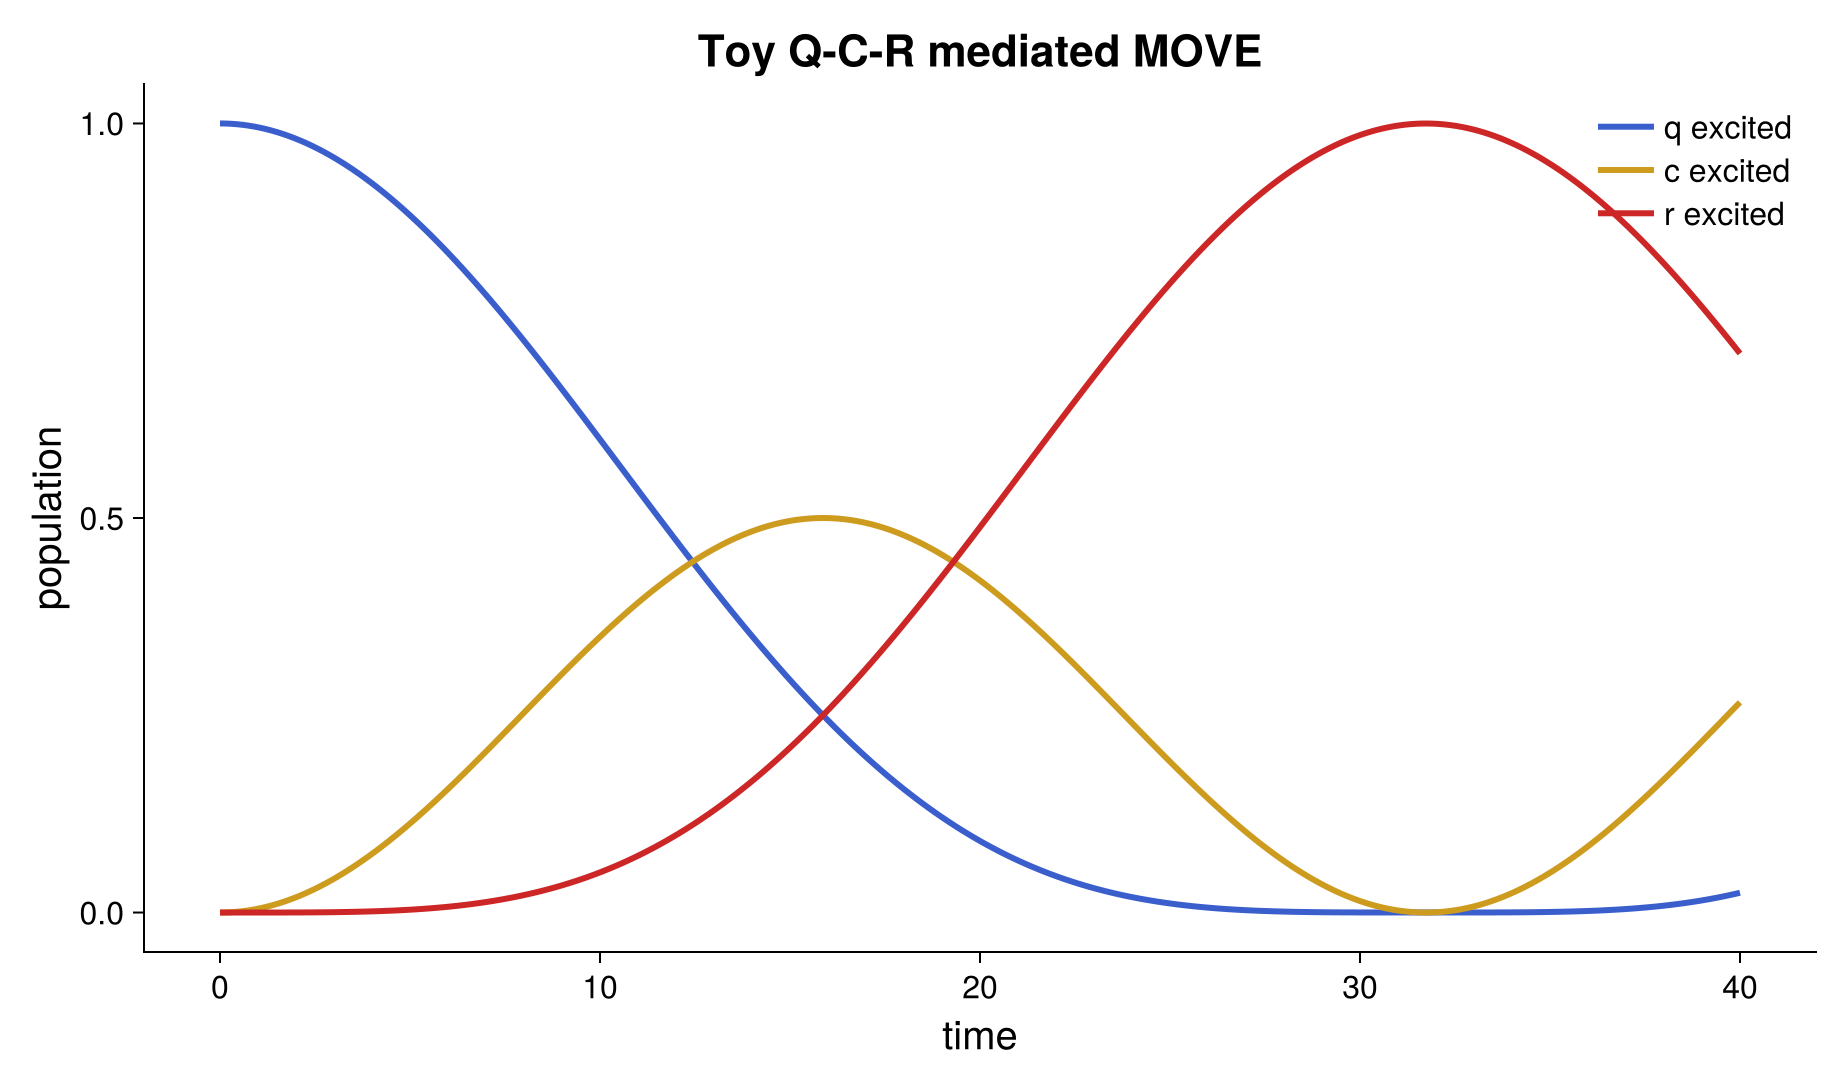

(move = (best_time = 31.7, transfer_probability = 0.99992, leakage = 6.0e-6), max_coupler_population = 0.49998, saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/workflow_toy_qcr_move.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/workflow_toy_qcr_move.png"))

In [6]:
toy_qcr = build_toy_qcr()
qcr_subspace = subspace_spec(toy_qcr; subsystem_levels = (q = [0, 1], r = [0, 1]))
qcr_tlist = collect(range(0.0, 40.0; length = 401))

qcr_trace = projected_unitary(toy_qcr, qcr_subspace, qcr_tlist)
qcr_best = best_move(qcr_trace; source_index = 3, target_index = 2)

qcr_result = evolve(toy_qcr, basis_state(toy_qcr; q = 1, c = 0, r = 0), qcr_tlist)
qcr_q = population_trace(qcr_result, :q, 1)
qcr_c = population_trace(qcr_result, :c, 1)
qcr_r = population_trace(qcr_result, :r, 1)

qcr_fig = line_figure(
    [
        (x = qcr_q.times, y = qcr_q.values, label = "q excited", color = :royalblue3),
        (x = qcr_c.times, y = qcr_c.values, label = "c excited", color = :goldenrod3),
        (x = qcr_r.times, y = qcr_r.values, label = "r excited", color = :firebrick3),
    ];
    title = "Toy Q-C-R mediated MOVE",
    xlabel = "time",
    ylabel = "population",
)
qcr_saved = save_figure(qcr_fig, project_root, "workflow_toy_qcr_move")
figure_exports[:workflow_toy_qcr_move] = qcr_saved

mediated_summary = (
    move = move_summary(qcr_best),
    max_coupler_population = round(maximum(qcr_c.values); digits = 6),
    saved = qcr_saved,
)

display(qcr_fig)
mediated_summary


## Step 4 - Build the reduced paper device at the parked point

With the exchange physics in hand, we now switch to the paper-aligned reduced device `QB1-TC1-CR-TC2-QB2`.

The same frozen local priors are used to construct two surrogate models:
- an effective Duffing-style chain for fast iteration,
- an exact-circuit chain for source-of-truth validation at reduced truncation.


In [7]:
pair = renger2026_model_pair(snapshot)

effective_spectrum = spectrum(pair.effective.system; levels = 6)
circuit_spectrum = spectrum(
    pair.circuit.system;
    levels = 6,
    hamiltonian_spec = pair.circuit.hamiltonian_spec,
)

parked_summary = (
    effective_subsystems = subsystem_rows(pair.effective.system),
    effective_couplings = coupling_rows(pair.effective.system),
    circuit_subsystems = subsystem_rows(pair.circuit.system),
    circuit_couplings = coupling_rows(pair.circuit.system),
    effective_spectrum = spectrum_summary(effective_spectrum),
    circuit_spectrum = spectrum_summary(circuit_spectrum),
)

parked_summary


(effective_subsystems = NamedTuple[(name = "QB1", type = "TunableTransmon", truncation = 5, frequency_or_energy = 14.92, EC = 0.199460916442, flux = 0.0), (name = "TC1", type = "TunableCoupler", truncation = 4, frequency_or_energy = 34.25, EC = 0.105, flux = 0.0), (name = "CR", type = "Resonator", truncation = 3, frequency_or_energy = 4.22, EC = missing, flux = missing), (name = "TC2", type = "TunableCoupler", truncation = 4, frequency_or_energy = 34.25, EC = 0.105, flux = 0.0), (name = "QB2", type = "TunableTransmon", truncation = 5, frequency_or_energy = 13.65, EC = 0.200581395349, flux = 0.0)], effective_couplings = NamedTuple[(source = "QB1", target = "TC1", type = "CapacitiveCoupling", parameter = "g", strength = 0.08423467931969232), (source = "TC1", target = "CR", type = "CapacitiveCoupling", parameter = "g", strength = 0.10597211986532118), (source = "CR", target = "TC2", type = "CapacitiveCoupling", parameter = "g", strength = 0.10597211986532118), (source = "TC2", target = "Q

## Step 5 - Compare effective versus exact-circuit behavior

The effective model is only useful if it tracks the low-energy structure of the exact-circuit model well enough to guide calibration. Here we compare the parked-point spectra and one small `TC1` flux sweep.

The two Hamiltonian forms do not share the same absolute energy zero, so the lower panel uses ground-referenced levels `E_n - E_0` rather than raw eigenvalues. The seeded effective model tracks the lowest transition reasonably well, but higher excited levels still drift by several GHz, so this should be read as a reduced-surrogate check rather than a fitted spectrum match.


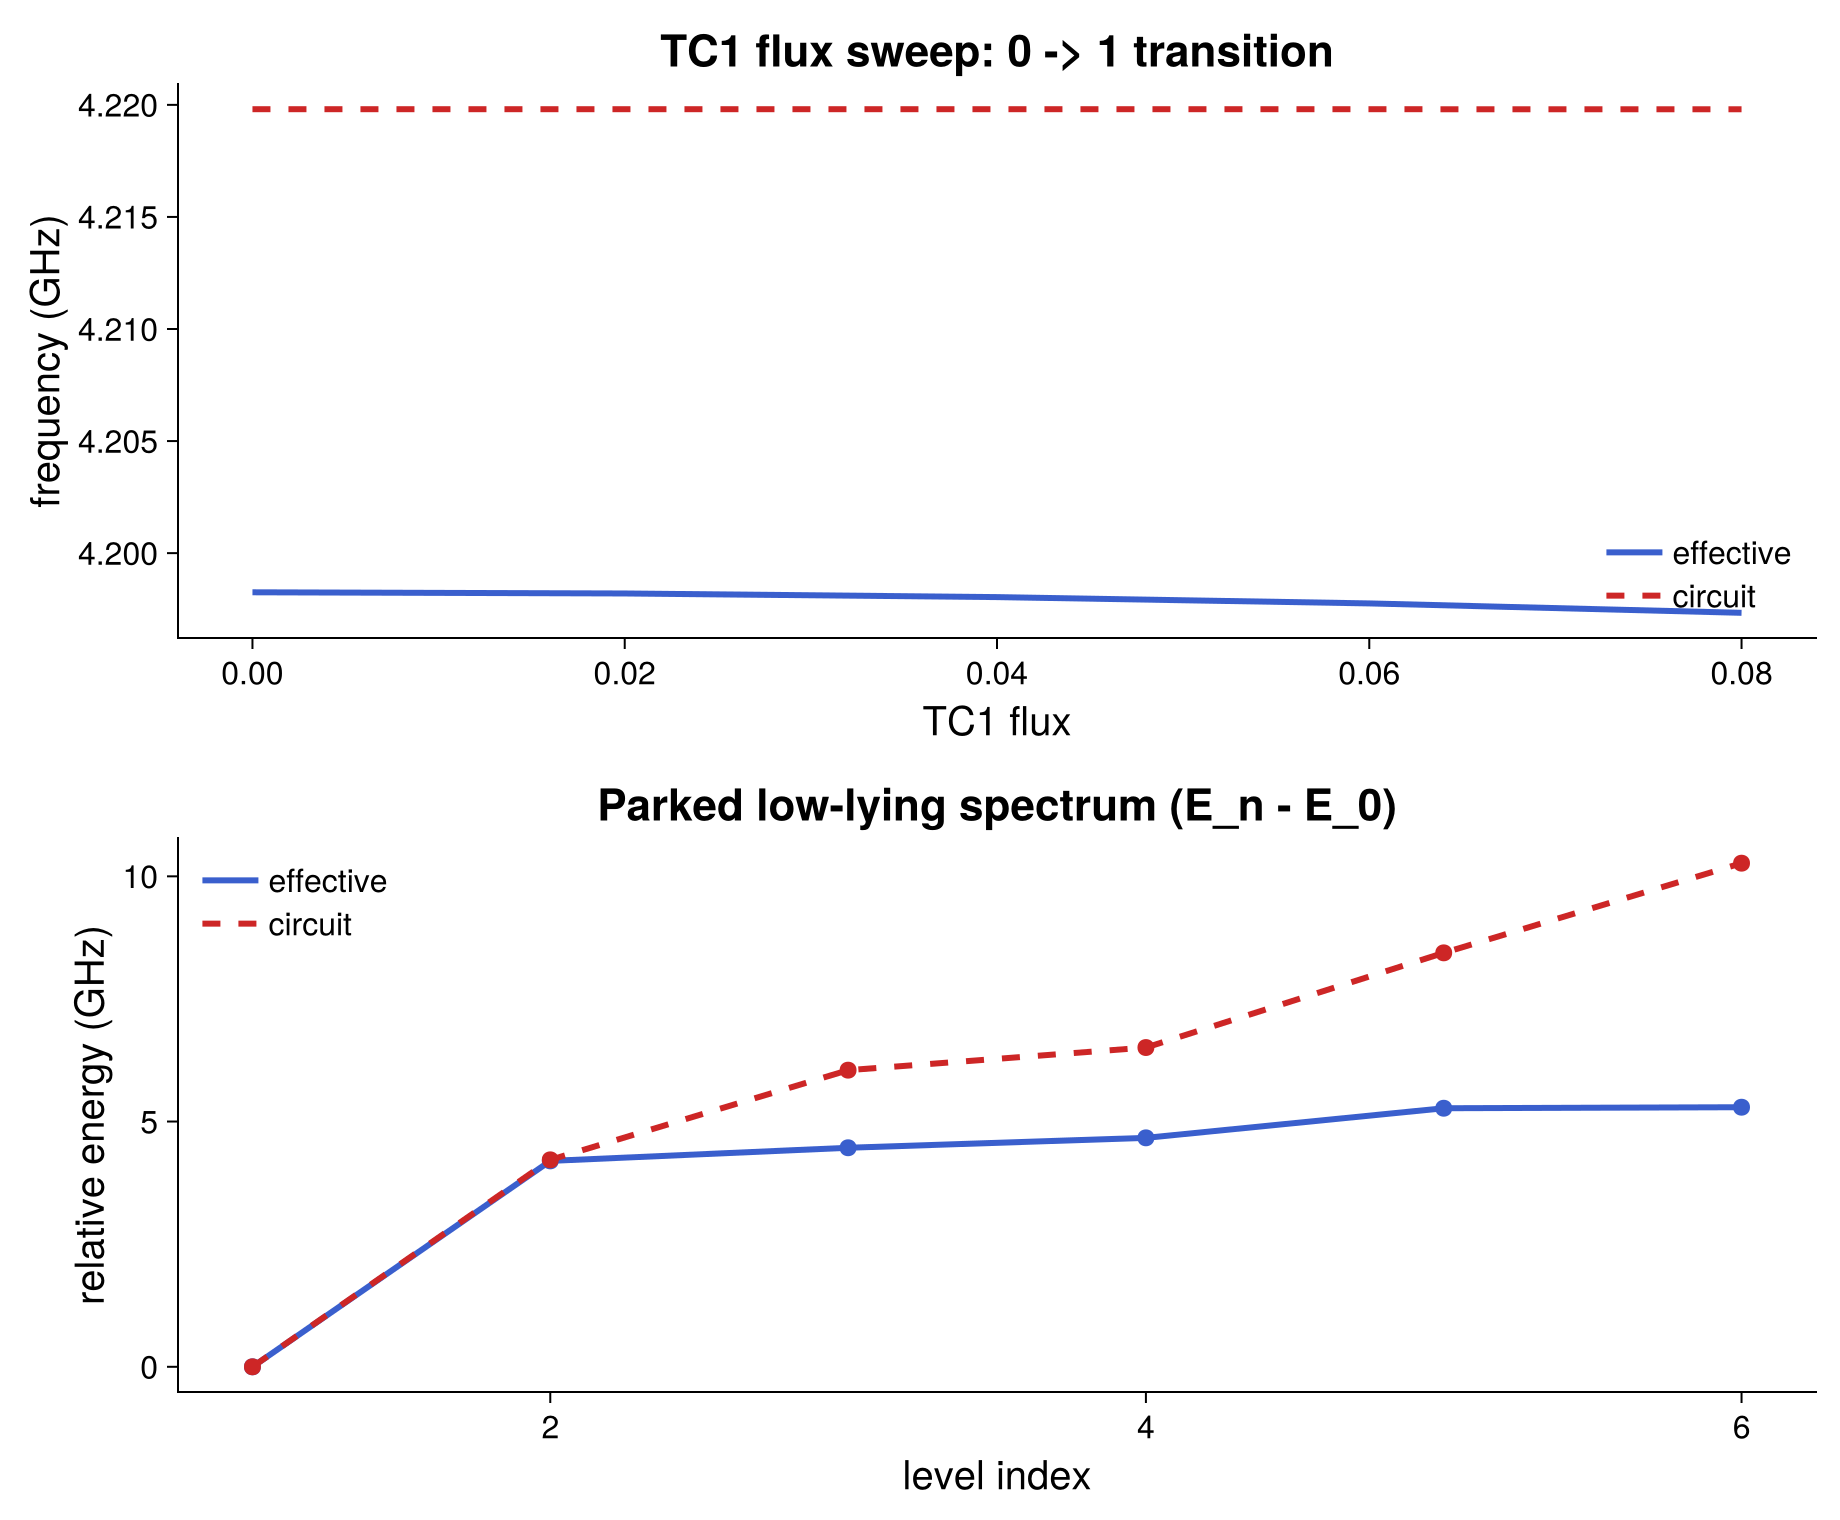

(absolute_ground_offset = 81.406335, absolute_level_deltas = [81.406335, 81.384779, 79.824258, 79.565367, 78.238394, 76.431081], level_deltas = [0.0, -0.021555, -1.582076, -1.840968, -3.16794, -4.975254], transition_deltas = [-0.021555, -1.560521, -0.258891, -1.326973, -1.807314], minimum_gap_delta = -0.022468, minimum_gap_flux_delta = 0.0, saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/workflow_effective_vs_circuit_comparison.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/workflow_effective_vs_circuit_comparison.png"))

In [8]:
spectrum_comparison = compare_model_spectra(
    pair.circuit.system,
    pair.effective.system;
    reference_hamiltonian_spec = pair.circuit.hamiltonian_spec,
    candidate_hamiltonian_spec = pair.effective.hamiltonian_spec,
    levels = 6,
)

flux_values = collect(range(0.0, 0.08; length = 5))
effective_sweep = simulate_sweep(
    pair.effective.system,
    SweepSpec(:TC1, :flux, flux_values; levels = 4);
    hamiltonian_spec = pair.effective.hamiltonian_spec,
)
circuit_sweep = simulate_sweep(
    pair.circuit.system,
    SweepSpec(:TC1, :flux, flux_values; levels = 4);
    hamiltonian_spec = pair.circuit.hamiltonian_spec,
)
gap_comparison = compare_minimum_gap(circuit_sweep, effective_sweep)

effective_transition = transition_curve(effective_sweep)
circuit_transition = transition_curve(circuit_sweep)
relative_effective_energies = effective_spectrum.energies .- effective_spectrum.energies[1]
relative_circuit_energies = circuit_spectrum.energies .- circuit_spectrum.energies[1]
absolute_ground_offset = spectrum_comparison.absolute_level_deltas[1]

comparison_fig = Figure(size = NOTEBOOK_TALL)
ax_transition = Axis(
    comparison_fig[1, 1];
    title = "TC1 flux sweep: 0 -> 1 transition",
    xlabel = "TC1 flux",
    ylabel = "frequency (GHz)",
)
lines!(ax_transition, effective_transition.values, effective_transition.data; label = "effective", color = :royalblue3, linewidth = 3)
lines!(ax_transition, circuit_transition.values, circuit_transition.data; label = "circuit", color = :firebrick3, linewidth = 3, linestyle = :dash)
axislegend(ax_transition; position = :rb)

ax_levels = Axis(
    comparison_fig[2, 1];
    title = "Parked low-lying spectrum (E_n - E_0)",
    xlabel = "level index",
    ylabel = "relative energy (GHz)",
)
level_index = collect(eachindex(relative_effective_energies))
lines!(ax_levels, level_index, relative_effective_energies; label = "effective", color = :royalblue3, linewidth = 3)
scatter!(ax_levels, level_index, relative_effective_energies; color = :royalblue3, markersize = 12)
lines!(ax_levels, level_index, relative_circuit_energies; label = "circuit", color = :firebrick3, linewidth = 3, linestyle = :dash)
scatter!(ax_levels, level_index, relative_circuit_energies; color = :firebrick3, markersize = 12)
axislegend(ax_levels; position = :lt)

comparison_saved = save_figure(comparison_fig, project_root, "workflow_effective_vs_circuit_comparison")
figure_exports[:workflow_effective_vs_circuit] = comparison_saved

comparison_summary = (
    absolute_ground_offset = round(absolute_ground_offset; digits = 6),
    absolute_level_deltas = round.(spectrum_comparison.absolute_level_deltas; digits = 6),
    level_deltas = round.(spectrum_comparison.level_deltas; digits = 6),
    transition_deltas = round.(spectrum_comparison.transition_deltas; digits = 6),
    minimum_gap_delta = round(gap_comparison.gap_delta; digits = 6),
    minimum_gap_flux_delta = round(gap_comparison.sweep_value_delta; digits = 6),
    saved = comparison_saved,
)

display(comparison_fig)
comparison_summary


## Step 6 - Remote logical gate concept: `MOVE -> CZ -> MOVE`

The paper's logical peripheral-qubit entangling workflow is not a direct native qubit-qubit interaction.

Instead, one qubit state is moved into the computational resonator, a native entangling interaction is applied between the second qubit and that bus degree of freedom, and the state is moved back out again. In shorthand:

`MOVE(QB1, CR) -> CZ(QB2, CR) -> MOVE(QB1, CR)`

This is the architectural reason the processor behaves as if it had effective all-to-all connectivity: the remote logical overhead is two MOVE operations plus one native entangling step, independent of graph distance.


## Step 7 - Calibrate CZ phase extraction on a compact exact-circuit testbed

The repository already has a validated exact-circuit CZ calibration path on a small tunable-coupler testbed. We use that compact system here because it is the cheapest place to teach the numerical machinery:
- define a dressed logical subspace,
- apply a flux control,
- extract projected unitaries,
- strip local `Z` phases if needed,
- measure the entangling phase.

This is a calibration and analysis tutorial section. It is not meant to replace the full paper-specific five-body gate construction.


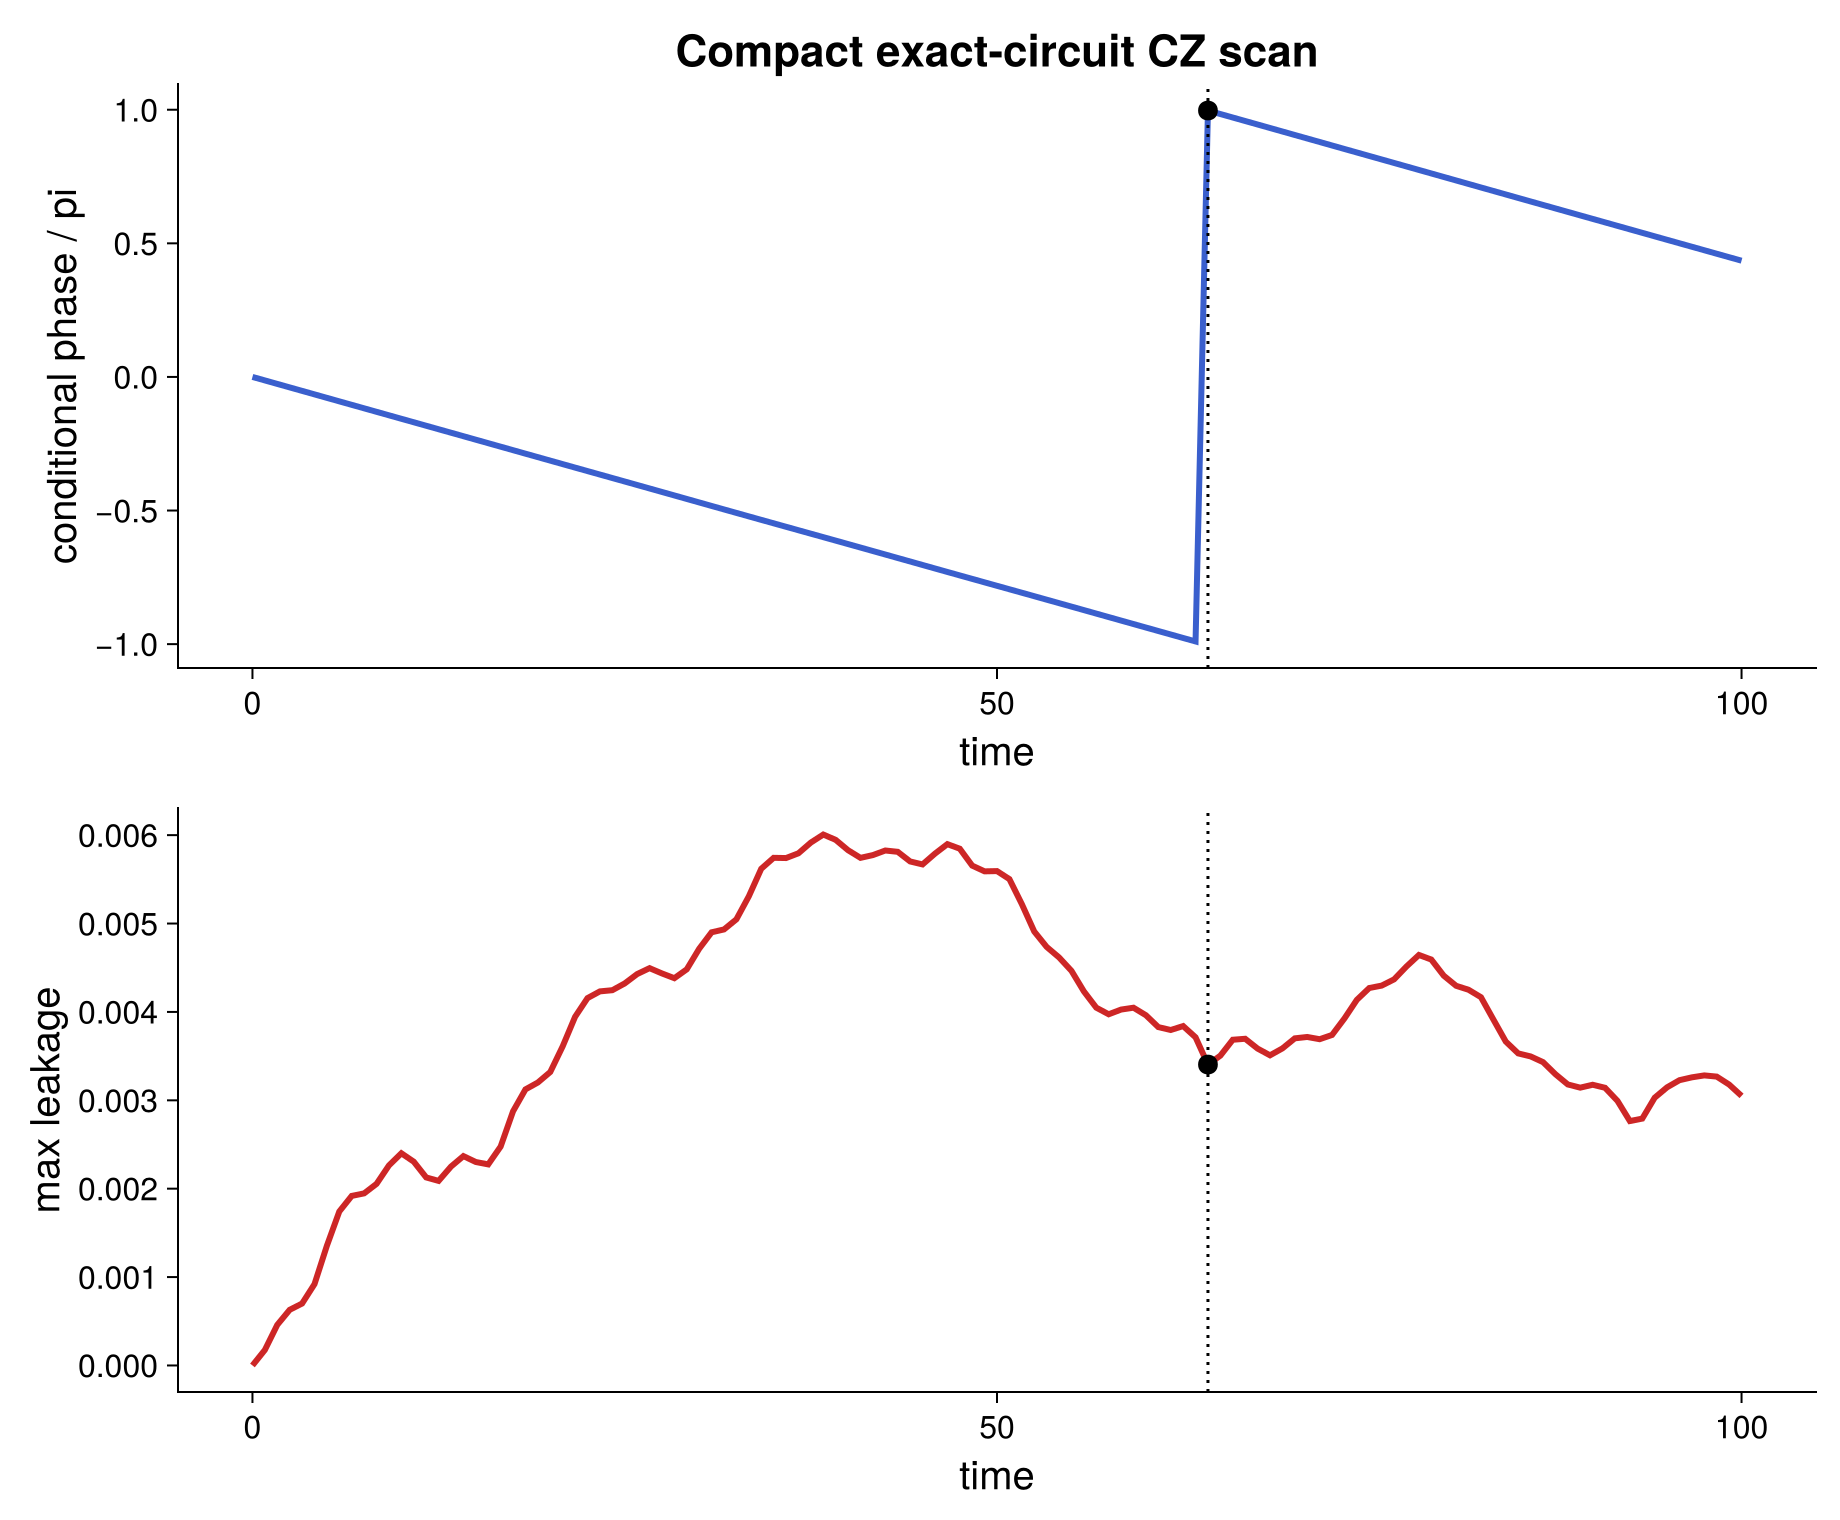

(cz = (best_time = 64.167, conditional_phase = 3.132184, conditional_phase_over_pi = 0.997005, phase_error = 0.009408, leakage = 0.003405), saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/workflow_compact_cz_scan.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/workflow_compact_cz_scan.png"))

In [9]:
compact_cz = build_compact_cz_testbed()
cz_subspace = subspace_spec(
    compact_cz.system;
    hamiltonian_spec = compact_cz.hamiltonian_spec,
    subsystem_levels = (q1 = [0, 1], q2 = [0, 1]),
    basis = :dressed_static,
)

cz_flux = FluxControl(:cz_flux, :c, (p, t) -> p.delta)
cz_tlist = collect(range(0.0, 100.0; length = 121))
cz_trace = projected_unitary(
    compact_cz.system,
    cz_subspace,
    cz_tlist;
    hamiltonian_spec = compact_cz.hamiltonian_spec,
    flux_controls = [cz_flux],
    params = (; delta = 0.04),
)
cz_best = best_cz(cz_trace)

phase_curve = [conditional_phase(U) / pi for U in cz_trace.unitaries]
leakage_curve = [maximum(view(cz_trace.leakages, :, idx)) for idx in eachindex(cz_trace.times)]

cz_fig = Figure(size = NOTEBOOK_TALL)
ax_phase = Axis(
    cz_fig[1, 1];
    title = "Compact exact-circuit CZ scan",
    xlabel = "time",
    ylabel = "conditional phase / pi",
)
lines!(ax_phase, cz_trace.times, phase_curve; color = :royalblue3, linewidth = 3)
scatter!(ax_phase, [cz_best.time], [cz_best.conditional_phase / pi]; color = :black, markersize = 14)
vlines!(ax_phase, [cz_best.time]; color = :black, linestyle = :dot)

ax_leakage = Axis(
    cz_fig[2, 1];
    xlabel = "time",
    ylabel = "max leakage",
)
lines!(ax_leakage, cz_trace.times, leakage_curve; color = :firebrick3, linewidth = 3)
scatter!(ax_leakage, [cz_best.time], [cz_best.leakage]; color = :black, markersize = 14)
vlines!(ax_leakage, [cz_best.time]; color = :black, linestyle = :dot)

cz_saved = save_figure(cz_fig, project_root, "workflow_compact_cz_scan")
figure_exports[:workflow_compact_cz_scan] = cz_saved

display(cz_fig)
(
    cz = cz_summary(cz_best),
    saved = cz_saved,
)


## Step 8 - Assemble a reduced remote-gate workflow summary

We now combine the main ingredients from the previous sections:
- the mediated MOVE timing from the resonant `Q-C-R` surrogate,
- the native CZ timing from the compact exact-circuit testbed,
- the logical paper sequence `MOVE -> CZ -> MOVE`.

The result below is deliberately a lightweight workflow summary rather than a full five-body pulse optimizer. It makes the structure explicit without pretending that the default tutorial run is already a full hardware calibration.


In [10]:
remote_gate_recipe = [
    (step = 1, operation = "MOVE(QB1, CR)", model = "toy Q-C-R surrogate", time = round(qcr_best.time; digits = 3), primary_metric = round(qcr_best.transfer_probability; digits = 6)),
    (step = 2, operation = "CZ(QB2, CR)", model = "compact exact-circuit surrogate", time = round(cz_best.time; digits = 3), primary_metric = round(cz_best.conditional_phase / pi; digits = 6)),
    (step = 3, operation = "MOVE(QB1, CR)", model = "toy Q-C-R surrogate", time = round(qcr_best.time; digits = 3), primary_metric = round(qcr_best.transfer_probability; digits = 6)),
]

remote_gate_summary = (
    estimated_total_sequence_time = round(2 * qcr_best.time + cz_best.time; digits = 3),
    move_transfer = round(qcr_best.transfer_probability; digits = 6),
    native_cz_phase_over_pi = round(cz_best.conditional_phase / pi; digits = 6),
    loose_leakage_budget = round(min(1.0, 2 * qcr_best.leakage + cz_best.leakage); digits = 6),
    note = "This is a staged reduced workflow summary, not a full five-body calibrated gate unitary.",
)

display(remote_gate_recipe)
remote_gate_summary


3-element Vector{@NamedTuple{step::Int64, operation::String, model::String, time::Float64, primary_metric::Float64}}:
 (step = 1, operation = "MOVE(QB1, CR)", model = "toy Q-C-R surrogate", time = 31.7, primary_metric = 0.99992)
 (step = 2, operation = "CZ(QB2, CR)", model = "compact exact-circuit surrogate", time = 64.167, primary_metric = 0.997005)
 (step = 3, operation = "MOVE(QB1, CR)", model = "toy Q-C-R surrogate", time = 31.7, primary_metric = 0.99992)

(estimated_total_sequence_time = 127.567, move_transfer = 0.99992, native_cz_phase_over_pi = 0.997005, loose_leakage_budget = 0.003416, note = "This is a staged reduced workflow summary, not a full five-body calibrated gate unitary.")

## Step 9 - Optional five-body exact-circuit extension

The reduced `QB1-TC1-CR-TC2-QB2` exact-circuit model is where the full paper-aligned workflow eventually has to land. The cell below is intentionally optional because it is the heaviest part of the notebook.

By default it is skipped. Set `RUN_OPTIONAL_FIVE_BODY = true` in the helper cell if you want to run a coarse phase probe directly on the five-body exact-circuit model.


In [13]:
if RUN_OPTIONAL_FIVE_BODY
    five_body_subspace = subspace_spec(
        pair.circuit.system;
        hamiltonian_spec = pair.circuit.hamiltonian_spec,
        subsystem_levels = (QB1 = [0, 1], QB2 = [0, 1]),
        basis = :dressed_static,
    )
    tc2_flux = FluxControl(:tc2_flux, :TC2, (p, t) -> p.delta)
    five_body_tlist = collect(range(0.0, 20.0; length = 41))
    five_body_trace = projected_unitary(
        pair.circuit.system,
        five_body_subspace,
        five_body_tlist;
        hamiltonian_spec = pair.circuit.hamiltonian_spec,
        flux_controls = [tc2_flux],
        params = (; delta = 0.01),
    )

    five_body_summary = (
        phase_range_over_pi = round.(extrema([conditional_phase(U) / pi for U in five_body_trace.unitaries]); digits = 6),
        max_leakage = round(maximum(five_body_trace.leakages); digits = 6),
        note = "This is only a coarse exact-circuit probe. A real five-body calibration still needs a denser scan and convergence checks.",
    )

    five_body_summary
else
    "Set RUN_OPTIONAL_FIVE_BODY = true in the helper cell to execute this coarse five-body exact-circuit probe."
end


"Set RUN_OPTIONAL_FIVE_BODY = true in the helper cell to execute this coarse five-body exact-circuit probe."

## Step 10 - Pitfalls and convergence checks

Keep these limits in mind when you interpret the numbers above:
- The early `Q-R` and `Q-C-R` sections are teaching models, not paper-fit device slices.
- The reduced paper device uses seeded couplings from local priors, not a completed coupled fit.
- Agreement between the effective and exact-circuit models should be checked with explicit truncation sweeps before it is treated as validated.
- A large diagonal phase is not automatically an entangling phase; use `conditional_phase(...)` and be aware of local `Z` freedom.
- The notebook stays in closed-system unitary dynamics only. There is no decoherence model here.


## Exercise

Try one of the following and compare the result against the default cells above:
- Increase the `Q-C-R` coupler truncation or adjust its `EJmax` and watch how the mediated MOVE time changes.
- Increase the exact-circuit `charge_cutoff` in the CZ testbed and check whether the best conditional phase or leakage shifts.
- Change the `TC1` flux sweep range in the reduced paper device and compare the effective versus exact-circuit gap proxy again.


In [12]:
# Exercise answer scaffold.
# Pick one variation, rerun the corresponding section, and summarize what changed.

exercise_notes = (
    variation = "replace with your chosen change",
    expected_effect = "write down your prediction before rerunning the section",
    observed_change = "fill this in after rerunning",
    interpretation = "did the change look like a truncation artifact, a coupling effect, or a control effect?",
)

exercise_notes


(variation = "replace with your chosen change", expected_effect = "write down your prediction before rerunning the section", observed_change = "fill this in after rerunning", interpretation = "did the change look like a truncation artifact, a coupling effect, or a control effect?")